## Clase 31 de Agosto

# Análisis estadístico calidad del aire CDMX

In [37]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Archivos
archivos = {
    2024: "aire/contaminantes_2024.csv",
    2025: "aire/contaminantes_2025.csv",
    2026: "aire/contaminantes_2026.csv"
}

## ETL

In [39]:
def cargar_contaminantes(ruta, anio):
    
    # Extract
    # Nos saltamos los primeros 9 renglones porque no forman parte

    temp = pd.read_csv(
        ruta,
        skiprows=9,
        low_memory=False
    )
    
    # Limpiamos nombres de columnas
    temp.columns = temp.columns.str.strip()
    
    # Homogenizamos columnas valor y value
    if "valor" in temp.columns:
        temp = temp.rename(columns={"valor": "value"})
    
    # Guardamos el año de procedencia
    temp["source_year"] = anio
    
    return temp

In [40]:
# Juntamos los 3 datasets
df = pd.concat(
    [
        cargar_contaminantes(ruta, anio)
        for anio, ruta in archivos.items()
    ],
    ignore_index=True
)

df.head()

,date,id_station,id_parameter,value,unit,source_year
0,2024-01-01 01:00:00,ACO,CO,NaN,15.000,2024
1,2024-01-01 01:00:00,ACO,NO,NaN,1.000,2024
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.000,2024
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.000,2024
4,2024-01-01 01:00:00,ACO,O3,NaN,1.000,2024


In [41]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 5394153
Columnas: 6


In [42]:
df.dtypes

date             object
id_station       object
id_parameter     object
value           float64
unit            float64
source_year       int64
dtype: object

In [44]:
df.isna().sum()

date                  0
id_station            0
id_parameter          0
value           2357916
unit             352512
source_year           0
dtype: int64

### Limpiamos los datos

In [48]:
# Homogenizamos tipos de datos

# Fecha
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    errors="coerce"
)

# Mediciones
df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

# Unidad
df["unit"] = pd.to_numeric(
    df["unit"],
    errors="coerce"
)

### Eliminamos NaNs

In [49]:
df = df.dropna().copy()
df = df.reset_index(drop=True)
df.isna().sum()

date            0
id_station      0
id_parameter    0
value           0
unit            0
source_year     0
dtype: int64

In [50]:
# Revisamos que si se hayan borrado
print("Dataset limpio:", df.shape)

Dataset limpio: (2864358, 6)


### Checamos y eliminamos duplicados

In [51]:
print("Duplicados:", df.duplicated().sum())

Duplicados: 0


## Feature Engineering

In [52]:
# Creamos variables apartir de date
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.day_name()

In [56]:
df.head()

,date,id_station,id_parameter,value,unit,source_year,year,month,day,hour,day_of_week
0,2024-01-01 01:00:00,AJM,CO,0.230,15.000,2024,2024,1,1,1,Monday
1,2024-01-01 01:00:00,AJM,NO,0.000,1.000,2024,2024,1,1,1,Monday
2,2024-01-01 01:00:00,AJM,NO2,10.000,1.000,2024,2024,1,1,1,Monday
3,2024-01-01 01:00:00,AJM,NOX,10.000,1.000,2024,2024,1,1,1,Monday
4,2024-01-01 01:00:00,AJM,O3,43.000,1.000,2024,2024,1,1,1,Monday


In [57]:
# Revisamos los datos de cada año
df.groupby("source_year")["date"].agg(["min", "max", "count"])

,min,max,count
source_year,,,
2024,2024-01-01 01:00:00,2024-12-31 23:00:00,1402125
2025,2025-01-01 00:00:00,2025-12-31 23:00:00,1425789
2026,2026-02-18 00:00:00,2026-02-28 23:00:00,36444


## Medidas de tendencia central

In [58]:
def calcular_moda(x):
    moda = x.mode()
    
    if len(moda) > 0:
        return moda.iloc[0]
    
    return np.nan


tendencia_central = (
    df
    .groupby(["source_year", "id_parameter"])["value"]
    .agg(
        media="mean",
        mediana="median",
        moda=calcular_moda
    )
    .reset_index()
)

tendencia_central.round(2)

,source_year,id_parameter,media,mediana,moda
0,2024,CO,0.470,0.360,0.250
1,2024,NO,13.620,3.000,1.000
2,2024,NO2,23.510,21.000,14.000
3,2024,NOX,37.190,25.000,14.000
4,2024,O3,32.430,25.000,1.000
5,2024,PM10,43.300,38.000,26.000
6,2024,PM2.5,20.420,18.000,13.000
7,2024,PMCO,19.350,16.000,6.000
8,2024,SO2,2.570,1.000,1.000
9,2025,CO,0.520,0.440,0.300


## Medidas de disperción

In [59]:
dispersion = (
    df
    .groupby(["source_year", "id_parameter"])["value"]
    .agg(
        varianza="var",
        desviacion_estandar="std"
    )
    .reset_index()
)

dispersion.round(2)

,source_year,id_parameter,varianza,desviacion_estandar
0,2024,CO,0.170,0.410
1,2024,NO,814.530,28.540
2,2024,NO2,194.690,13.950
3,2024,NOX,"1,395.990",37.360
4,2024,O3,789.940,28.110
5,2024,PM10,817.830,28.600
6,2024,PM2.5,174.320,13.200
7,2024,PMCO,211.750,14.550
8,2024,SO2,23.190,4.820
9,2025,CO,0.140,0.380


## Distribuciones

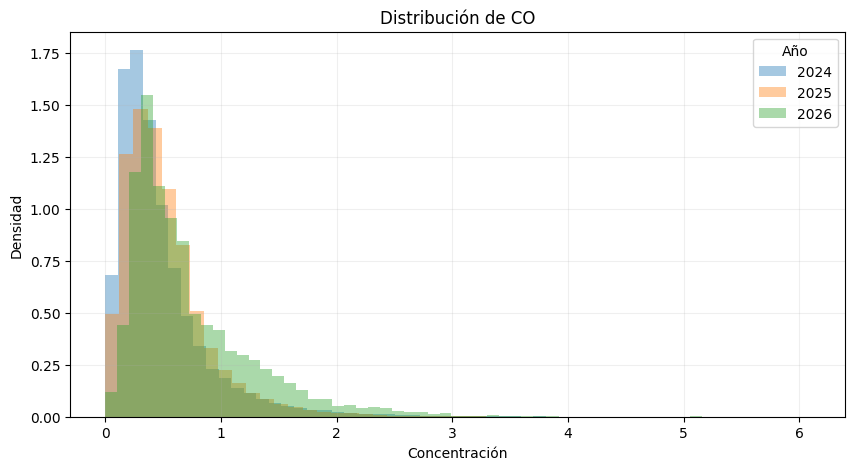

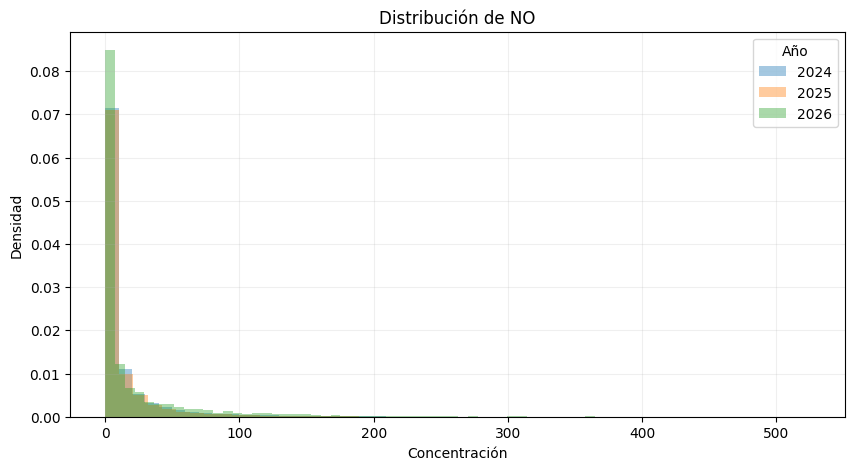

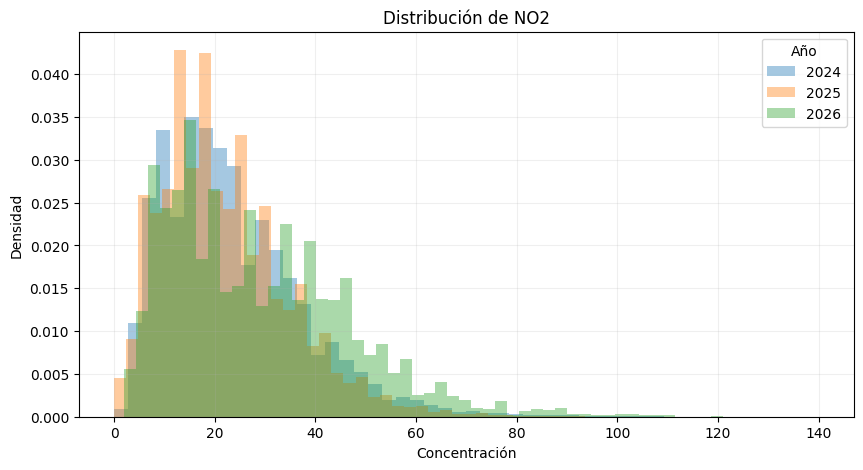

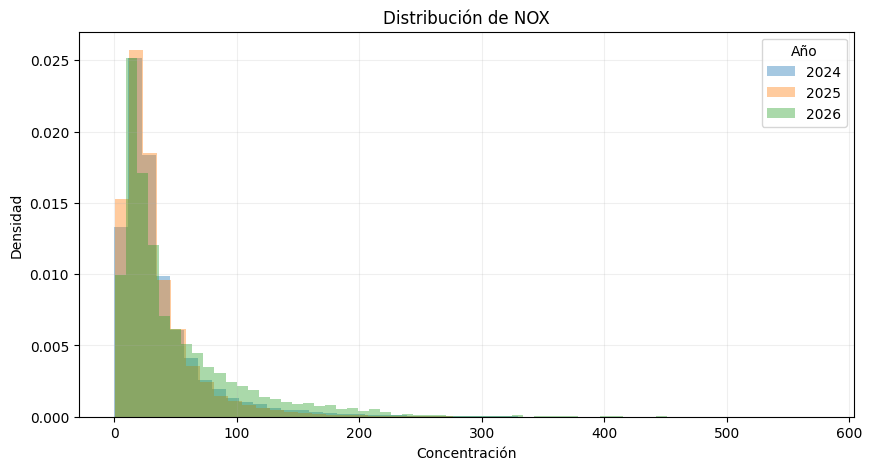

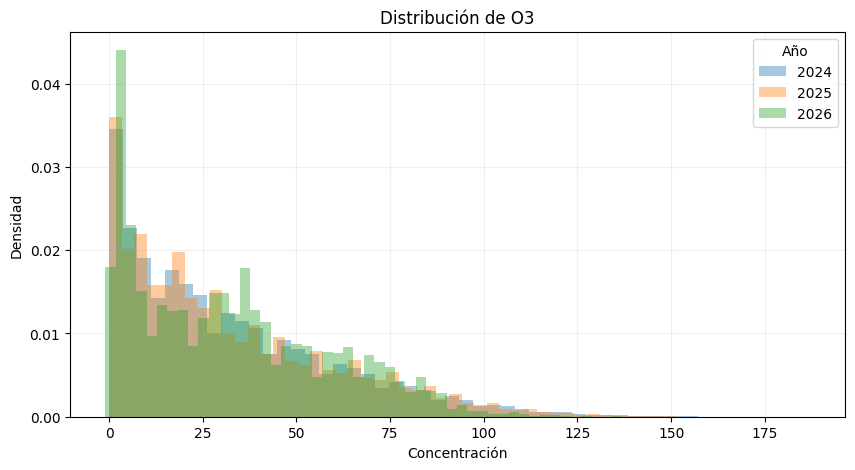

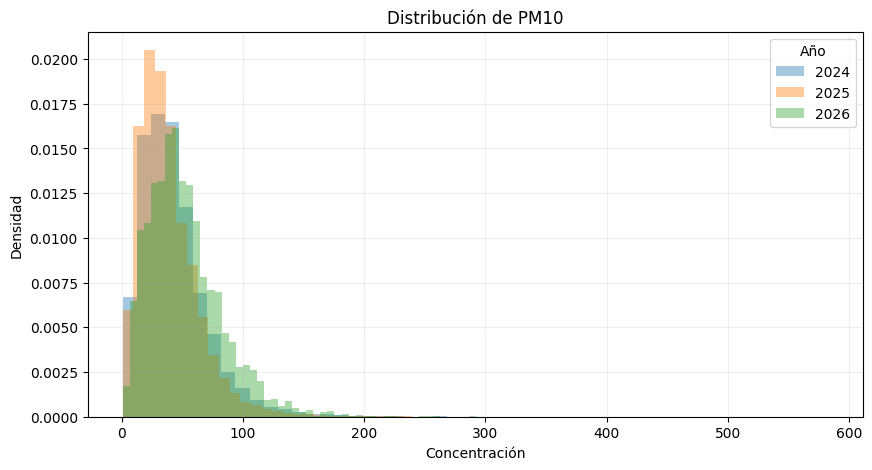

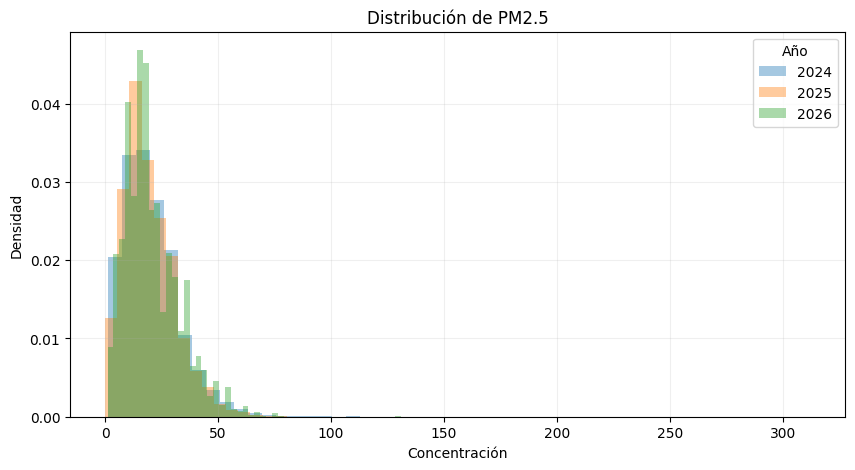

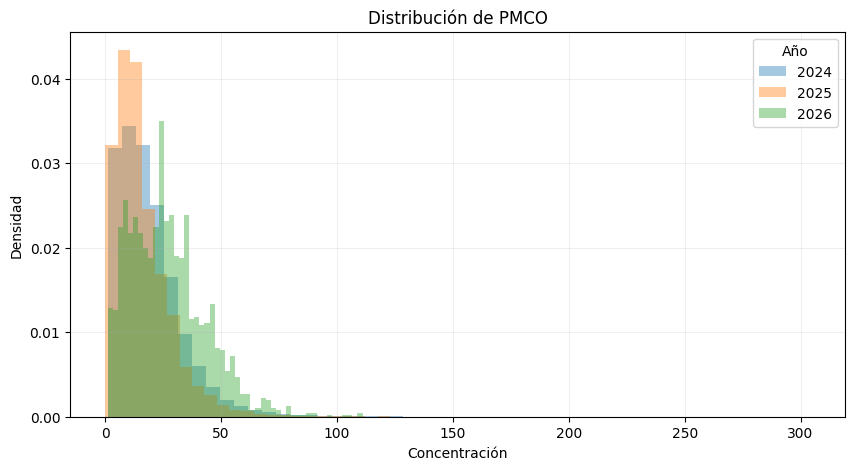

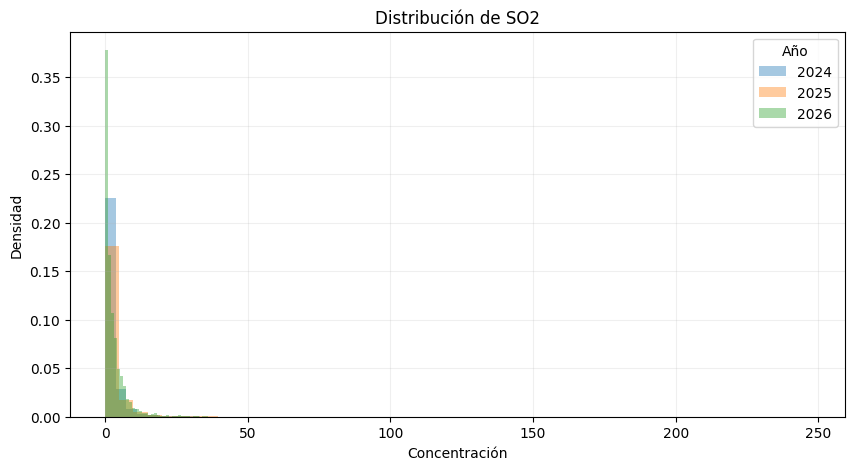

In [60]:
contaminantes = sorted(df["id_parameter"].unique())
anios = sorted(df["source_year"].unique())

for contaminante in contaminantes:
    
    plt.figure(figsize=(10, 5))
    
    datos_contaminante = df[
        df["id_parameter"] == contaminante
    ]
    
    for anio in anios:
        
        datos_anio = datos_contaminante[
            datos_contaminante["source_year"] == anio
        ]["value"]
        
        plt.hist(
            datos_anio,
            bins=50,
            alpha=0.4,
            density=True,
            label=str(anio)
        )
    
    plt.title(f"Distribución de {contaminante}")
    plt.xlabel("Concentración")
    plt.ylabel("Densidad")
    plt.legend(title="Año")
    plt.grid(alpha=0.2)
    
    plt.show()